# Exploratory Data Analysis (EDA) 

**Cách đọc cột `No-show`:** `No` = bệnh nhân **có đến**. `Yes` = bệnh nhân **vắng mặt**.


## 0. Thư viện và đọc dữ liệu


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "noshowappointments-kagglev2-may-2016.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,"29,872,499,824,296.00",5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,"558,997,776,694,438.00",5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,"4,262,962,299,951.00",5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,"867,951,213,174.00",5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,"8,841,186,448,183.00",5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## 1. Exploratory Data Analysis

Mục tiêu phần này: biết bảng đang chứa gì, trước khi sửa bất kỳ ô nào.


In [3]:
# How many rows and columns does the table have? (shape)
# Bảng có bao nhiêu dòng, bao nhiêu cột? (shape)
print(df.shape)


(110527, 14)


In [4]:
# How many rows and columns does the table have, what is each column named, what is its data type, and how many non-missing values does each column still have? (info)
# Có bao nhiêu dòng, bao nhiêu cột, mỗi cột tên gì, kiểu dữ liệu gì, và còn bao nhiêu giá trị không bị thiếu? (info)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [5]:
# What do the last few rows of the table look like? (tail)
# Vài dòng cuối của bảng trông như thế nào? (tail)
display(df.tail())


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,"2,572,134,369,293.00",5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,"3,596,266,328,735.00",5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,"15,576,631,729,893.00",5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,"92,134,931,435,557.00",5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,"377,511,518,121,127.00",5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


In [6]:
# How many different values does each column have? Show them in a one-column table named nunique.
# Mỗi cột có bao nhiêu giá trị khác nhau? Hiện thành bảng một cột tên nunique.
df.nunique().to_frame("nunique")


,nunique
PatientId,62299
AppointmentID,110527
Gender,2
ScheduledDay,103549
AppointmentDay,27
Age,104
Neighbourhood,81
Scholarship,2
Hipertension,2
Diabetes,2


| Nhóm | Cột |
| --- | --- |
| Định danh | `PatientId`, `AppointmentID` |
| Thời gian | `ScheduledDay` (lúc đặt lịch), `AppointmentDay` (ngày khám) |
| Bệnh nhân | `Gender`, `Age`, `Neighbourhood` |
| Cờ 0/1 | `Scholarship`, `Hipertension`, `Diabetes`, `Alcoholism`, `SMS_received` |
| Mức độ | `Handcap` |
| Nhãn | `No-show` |

`Hipertension` và `Handcap` là lỗi chính tả trong file gốc. Phần làm sạch sẽ đổi tên, không đổi giá trị.


### 1.2. Đưa ngày về kiểu datetime


In [7]:
# Convert ScheduledDay and AppointmentDay with pd.to_datetime(..., utc=True). The first line is the model.
# Đưa ScheduledDay và AppointmentDay về datetime bằng pd.to_datetime(..., utc=True). Dòng đầu là mẫu.

df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"], utc=True)
df["AppointmentDay"] = pd.to_datetime(df['AppointmentDay'], utc = True)

# What is the earliest and latest date an appointment was scheduled?
# Ngày đặt lịch sớm nhất và muộn nhất là ngày nào?
print("Đặt lịch từ", df["ScheduledDay"].min().date(), "đến", df["ScheduledDay"].max().date())

# What is the earliest and latest appointment date?
# Ngày khám sớm nhất và muộn nhất là ngày nào?
print("Ngày khám từ", df["AppointmentDay"].min().date(), "đến", df['AppointmentDay'].max().date())

# What do the first few scheduled dates and appointment dates look like side by side?
# Vài dòng đầu của ngày đặt lịch và ngày khám trông như thế nào?
df[["ScheduledDay", "AppointmentDay"]].head()


Đặt lịch từ 2015-11-10 đến 2016-06-08
Ngày khám từ 2016-04-29 đến 2016-06-08


,ScheduledDay,AppointmentDay
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00


**Tự trả lời**

Đọc output ngày giờ rồi trả lời.

1. `ScheduledDay` có cả giờ không? `AppointmentDay` trong file gốc là giờ nào, nên dùng được giờ khám không?
2. Ngày khám từ ngày nào đến ngày nào? Ngày đặt lịch bắt đầu sớm hơn hay muộn hơn ngày khám?


### 1.3. Thứ trong tuần

`dayofweek` của pandas: **0 = thứ Hai**, **6 = Chủ Nhật**.


In [9]:
# dayofweek: 0 = Monday, 6 = Sunday. The ScheduledDay line is the model. Do the same for AppointmentDay (dt.dayofweek).
# dayofweek: 0 = thứ Hai, 6 = Chủ Nhật. Dòng ScheduledDay là mẫu. Làm tương tự cho AppointmentDay (dt.dayofweek).

WEEKDAY = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

df["sch_weekday"] = df["ScheduledDay"].dt.dayofweek
df["app_weekday"] = df["AppointmentDay"].dt.dayofweek

# How many appointments were scheduled on each weekday? value_counts, then sort_index, then rename with WEEKDAY.
# Mỗi thứ có bao nhiêu lượt đặt lịch? value_counts, rồi sort_index, rồi đổi tên bằng WEEKDAY.
print("Thứ đặt lịch")
display(df["sch_weekday"].value_counts().sort_index().rename(index=dict(enumerate(WEEKDAY))))

# How many appointments fall on each weekday? Same steps as the line above.
# Mỗi thứ có bao nhiêu ngày khám? Làm cùng các bước với dòng trên.
print("Thứ ngày khám")
display(df["app_weekday"].value_counts().sort_index().rename(index=dict(enumerate(WEEKDAY))))


Thứ đặt lịch


sch_weekday
Mon    23085
Tue    26168
Wed    24262
Thu    18073
Fri    18915
Sat       24
Name: count, dtype: int64

Thứ ngày khám


app_weekday
Mon    22715
Tue    25640
Wed    25867
Thu    17247
Fri    19019
Sat       39
Name: count, dtype: int64

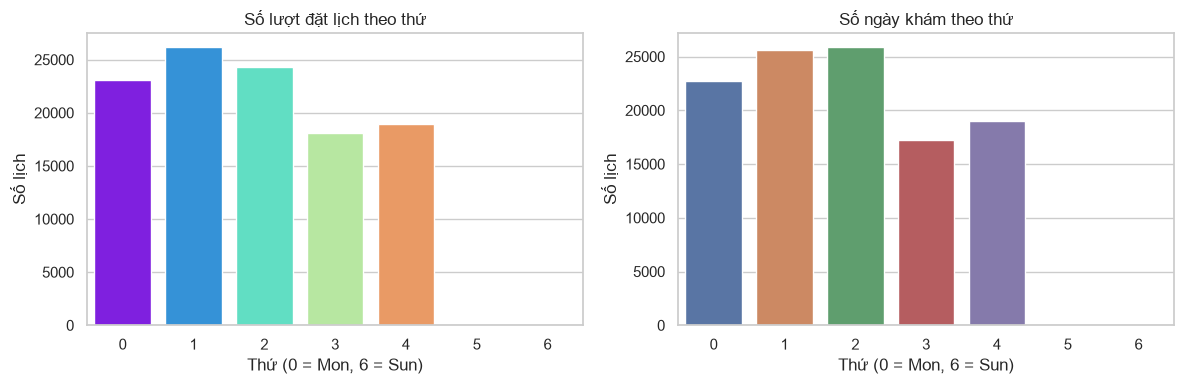

In [10]:
# The left chart is the model. Draw the same countplot for app_weekday on axes[1], title "Số ngày khám theo thứ".
# Biểu đồ trái là mẫu. Vẽ cùng kiểu cho app_weekday trên axes[1], tiêu đề "Số ngày khám theo thứ".

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(
    data=df,
    x="sch_weekday",
    order=range(7),
    hue="sch_weekday",
    palette="rainbow",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Số lượt đặt lịch theo thứ")
axes[0].set_xlabel("Thứ (0 = Mon, 6 = Sun)")
axes[0].set_ylabel("Số lịch")

sns.countplot(
    data=df,
    x='app_weekday',
    order=range(7),
    hue='app_weekday',
    palette="deep",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Số ngày khám theo thứ")
axes[1].set_xlabel("Thứ (0 = Mon, 6 = Sun)")
axes[1].set_ylabel("Số lịch")
plt.tight_layout()
plt.show()


**Nhận xét hình**

Đọc hai biểu đồ rồi trả lời. Mỗi câu phải có số lấy từ hình.

1. Lịch đặt và ngày khám tập trung vào những thứ nào? Thứ nào đông nhất ở ngày khám, khoảng bao nhiêu lịch?
2. Thứ Bảy có bao nhiêu lượt đặt lịch và bao nhiêu ngày khám? So với các ngày trong tuần thì thế nào?
3. Mã thứ 6 (Chủ Nhật) có xuất hiện trên hình không? Điều đó nói gì về lịch phòng khám?


#### Trả lời:
1. Lịch đặt và ngày khám tập trung vào thứ Hai, thứ Ba, và thứ Tư. Ở biểu đồ số ngày khám theo thứ, ngày đông nhất là thứ Tư ( số lượng khoảng 26000 lịch)
2. Thứ Bảy số lượt đặt lịch và ngày khám xấp xỉ bằng 0 (có thể chỉ ở mức vài chục). So với các ngày trong tuần thì là hoàn toàn không đáng kể.
3. Mã thứ 6 (Chủ Nhật) có xuất hiện trên hình, nhưng hoàn toàn không có cột dữ liệu tương ứng. Điều đó có thể cho thấy phòng khám không hoạt động vào Chủ Nhật hoặc có hoạt động nhưng không có ai đặt lịch

## 2. Data Cleaning

Đổi tên cột bị sai chính tả, và bỏ dấu `_`, `-` trong tên cột. Dòng `Hipertension` là mẫu. Ba dòng còn lại điền:

- `Handcap` → `Handicap`
- `SMS_received` → `SMSreceived`
- `No-show` → `Noshow`

Sau đó bỏ mã định danh không dùng cho biểu đồ, và gom tuổi thành nhóm. `Neighbourhood` có nhiều mức; mình giữ lại một bảng tỷ lệ có mặt rồi mới bỏ khỏi bảng phân tích chi tiết, vì biến giả theo từng khu phố sẽ nuốt heatmap.


In [11]:
df = df.rename(
    columns={
        "Hipertension": "Hypertension",
        "Handcap": 'Handicap',
        "SMS_received": 'SMSreceived',
        "No-show": 'Noshow',
    }
)
df.columns.tolist()


['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hypertension',
 'Diabetes',
 'Alcoholism',
 'Handicap',
 'SMSreceived',
 'Noshow',
 'sch_weekday',
 'app_weekday']

In [12]:
# For each neighbourhood, how many appointments are there and what share showed up (Noshow == "No")? Sort by show_rate. What is the median show rate, and which 5 neighbourhoods are lowest and highest?
# Mỗi khu phố có bao nhiêu lịch và tỷ lệ có mặt bao nhiêu (Noshow == "No")? Sắp theo show_rate. Trung vị tỷ lệ có mặt là bao nhiêu, 5 khu thấp nhất và 5 khu cao nhất là khu nào?

show = df["Noshow"].eq("No").astype(int)
neigh = (
    df.assign(showed=show)
    .groupby("Neighbourhood")
    .agg(n=("showed", "size"), show_rate=("showed", "mean"))
    .sort_values("show_rate")
)
print("Số khu phố:", len(neigh))
print("Trung vị tỷ lệ có mặt:", f"{neigh['show_rate'].median():.1%}")
print("Thấp nhất")
display(neigh.head(5))
print("Cao nhất")
display(neigh.tail(5))


Số khu phố: 81
Trung vị tỷ lệ có mặt: 80.2%
Thấp nhất


,n,show_rate
Neighbourhood,,
ILHAS OCEÂNICAS DE TRINDADE,2,0.00
SANTOS DUMONT,1276,0.71
SANTA CECÍLIA,448,0.73
SANTA CLARA,506,0.74
ITARARÉ,3514,0.74


Cao nhất


,n,show_rate
Neighbourhood,,
SOLON BORGES,469,0.85
MÁRIO CYPRESTE,371,0.85
AEROPORTO,8,0.88
ILHA DO BOI,35,0.91
PARQUE INDUSTRIAL,1,1.00


**Tự trả lời**

Đọc bảng `neigh` rồi trả lời. Mỗi câu phải có số.

1. Có bao nhiêu khu phố? Trung vị tỷ lệ có mặt là bao nhiêu?
2. Khu có tỷ lệ thấp nhất và cao nhất là khu nào, tỷ lệ bao nhiêu, và mỗi khu có bao nhiêu lịch?
3. Vì sao không kết luận "khu có tỷ lệ 0 là khu không ai đến"?


In [13]:
# What is the youngest and oldest age? How many rows have Age < 0, Age == 0, and Age > 100? Drop rows with negative age and print how many rows remain.
# Tuổi nhỏ nhất và lớn nhất là bao nhiêu? Có bao nhiêu dòng Age < 0, Age = 0, Age > 100? Bỏ dòng tuổi âm rồi in số dòng còn lại.

print("Tuổi nhỏ nhất / lớn nhất:", df["Age"].min(), "/", df["Age"].max())
print("Số dòng Age < 0:", int((df["Age"] < 0).sum()))
print("Số dòng Age = 0:", int((df["Age"] == 0).sum()))
print("Số dòng Age > 100:", int((df["Age"] > 100).sum()))

df = df.loc[df["Age"] >= 0].copy()
print("Còn lại sau khi bỏ tuổi âm:", df.shape[0], "dòng")


Tuổi nhỏ nhất / lớn nhất: -1 / 115
Số dòng Age < 0: 1
Số dòng Age = 0: 3539
Số dòng Age > 100: 7
Còn lại sau khi bỏ tuổi âm: 110526 dòng


In [14]:
# Group Age into bins of width 20, starting at 1, with the right edge excluded (right=False). How many rows are in each age group? How many Age == 0 rows fall outside the bins?
# Gom Age thành nhóm rộng 20 tuổi, bắt đầu từ 1, không gồm mép phải (right=False). Mỗi nhóm tuổi có bao nhiêu dòng? Có bao nhiêu dòng Age == 0 nằm ngoài các nhóm?

labels = [f"{i} - {i + 19}" for i in range(1, 118, 20)]
df["Age_group"] = pd.cut(
    df["Age"],
    bins=range(1, 130, 20),
    right=False,
    labels=labels,
)
print(df["Age_group"].value_counts(dropna=False).sort_index())
print("Tuổi 0 nằm ngoài các bin (bắt đầu từ 1):", int(df["Age_group"].isna().sum() - (df["Age"] < 0).sum()))


Age_group
1 - 20       28309
21 - 40      28835
41 - 60      30081
61 - 80      16910
81 - 100      2845
101 - 120        7
NaN           3539
Name: count, dtype: int64
Tuổi 0 nằm ngoài các bin (bắt đầu từ 1): 3539


**Tự trả lời**

Đọc output nhóm tuổi rồi trả lời.

1. Các nhóm tuổi bước bao nhiêu năm? Kể tên vài nhóm đầu.
2. Tuổi 0 có bao nhiêu dòng? Những dòng đó có nằm trong một nhóm tuổi không? Vì sao?
3. Dòng tuổi âm đã được xử lý ra sao, và vì sao bỏ dòng đó?


In [15]:
# Drop PatientId, AppointmentID, and Neighbourhood. They are not used in the charts below.
# Bỏ PatientId, AppointmentID và Neighbourhood. Ba cột này không dùng cho biểu đồ phía dưới.

df = df.drop(columns=["PatientId", "AppointmentID", "Neighbourhood"])
df.head()


,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSreceived,Noshow,sch_weekday,app_weekday,Age_group
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,0,1,0,0,0,0,No,4,4,61 - 80
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,0,0,0,0,0,0,No,4,4,41 - 60
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,0,0,0,0,0,0,No,4,4,61 - 80
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,0,0,0,0,0,0,No,4,4,1 - 20
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,0,1,1,0,0,0,No,4,4,41 - 60


In [16]:
# For the numeric columns, what are the count, mean, min, and max? (describe)
# Với các cột số, count, mean, min và max là bao nhiêu? (describe)
df.describe()


,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSreceived,sch_weekday,app_weekday
count,"110,526.00","110,526.00","110,526.00","110,526.00","110,526.00","110,526.00","110,526.00","110,526.00","110,526.00"
mean,37.09,0.10,0.20,0.07,0.03,0.02,0.32,1.85,1.86
std,23.11,0.30,0.40,0.26,0.17,0.16,0.47,1.38,1.37
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
50%,37.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,2.00
75%,55.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00,3.00
max,115.00,1.00,1.00,1.00,1.00,4.00,1.00,5.00,5.00


## 3. Biến mục tiêu `Noshow`

`Noshow = No`: có đến. `Noshow = Yes`: vắng mặt.


In [17]:
# For Noshow, how many appointments showed up (No) and how many were absent (Yes)? Also give each label as a percent (normalize=True, then multiply by 100).
# Với cột Noshow, có bao nhiêu lịch có đến (No) và bao nhiêu lịch vắng (Yes)? Mỗi nhãn chiếm bao nhiêu phần trăm (normalize=True, rồi nhân 100)?

counts = df["Noshow"].value_counts()
share = df["Noshow"].value_counts(normalize=True).mul(100)
target = pd.DataFrame({"count": counts, "percent": share})
target


,count,percent
Noshow,,
No,88207,79.81
Yes,22319,20.19


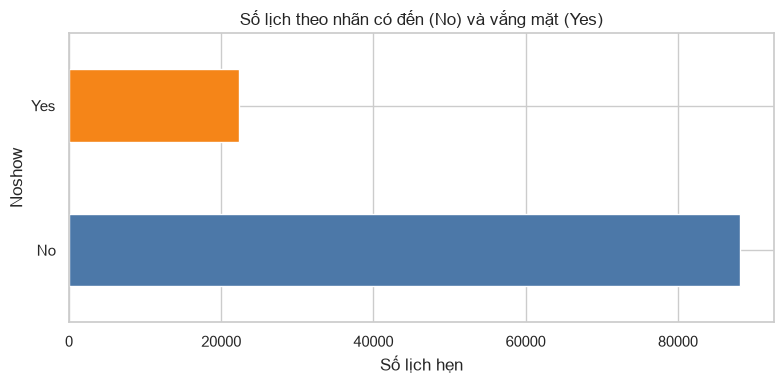

In [18]:
# How many appointments showed up (Noshow == "No") and how many were absent (Noshow == "Yes")? Draw a horizontal bar chart (kind="barh") of the Noshow column.
# Có bao nhiêu lịch có đến (Noshow == "No") và bao nhiêu lịch vắng (Noshow == "Yes")? Vẽ biểu đồ cột ngang (kind="barh") của cột Noshow.

ax = df["Noshow"].value_counts().plot(kind="barh", figsize=(8, 4), color=["#4C78A8", "#F58518"])
ax.set_xlabel("Số lịch hẹn")
ax.set_ylabel("Noshow")
ax.set_title("Số lịch theo nhãn có đến (No) và vắng mặt (Yes)")
plt.tight_layout()
plt.show()


**Tự trả lời**

Đọc biểu đồ rồi trả lời. Mỗi câu phải có số lấy từ hình.

1. Có bao nhiêu lịch có đến (`No`) và bao nhiêu lịch vắng (`Yes`)? Mỗi nhãn chiếm bao nhiêu phần trăm?
2. Nhãn lệch về phía nào? Nếu một mô hình luôn đoán "ai cũng đến", accuracy khoảng bao nhiêu, và vì sao con số đó chưa nói lên mô hình tốt?


#### Trả lời
1. Có khoảng 88000 lịch có đến (Chiếm ~80%) và khoảng 22000 lịch vắng (chiếm ~20%).
2. Nhãn lệch về phía "No". Nếu một mô hình luôn đoán "ai cũng đến", accuracy khoảng 80%. Con số đó chưa nói lên mô hình tốt vì mô hình sẽ dự đoán sai 100% các trường hợp bệnh nhân thực sự vắng mặt (nhãn Yes), trong khi việc nhận diện những người vắng mặt mới là mục tiêu cốt lõi của bài toán nhằm đưa ra biện pháp xử lý.

## 4. Missing values

Phần trăm ô trống trên từng cột. Bộ này không có giá trị thiếu ở file gốc; ô dưới dùng để kiểm tra lại sau các bước đổi kiểu.


,column,percent_missing
0,Gender,0.00
1,ScheduledDay,0.00
2,AppointmentDay,0.00
3,Age,0.00
4,Scholarship,0.00
5,Hypertension,0.00
6,Diabetes,0.00
7,Alcoholism,0.00
8,Handicap,0.00
9,SMSreceived,0.00


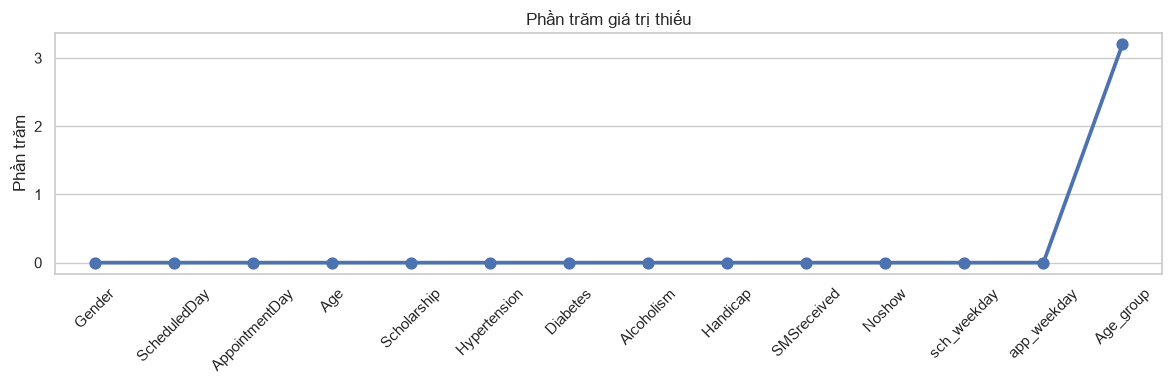

In [19]:
# What percent of each column is missing? Use isnull().mean(), then multiply by 100.
# Mỗi cột thiếu bao nhiêu phần trăm? Dùng isnull().mean(), rồi nhân 100.

missing = pd.DataFrame(
    {"column": df.columns, "percent_missing": df.isnull().mean().mul(100).to_numpy()}
)
display(missing)

fig, ax = plt.subplots(figsize=(12, 4))
sns.pointplot(data=missing, x="column", y="percent_missing", ax=ax)
ax.set_title("Phần trăm giá trị thiếu")
ax.set_xlabel("")
ax.set_ylabel("Phần trăm")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Missing data**

Đọc bảng và biểu đồ phần trăm thiếu rồi trả lời. Khi một bộ khác có thiếu dữ liệu, quy tắc thường dùng trên Kaggle là:

- Thiếu ít: cân nhắc điền theo trung vị / nhóm, hoặc mô hình đơn giản, tùy cột đó có được phép suy từ cột khác hay không.
- Thiếu rất nhiều (khoảng trên 30–40%): cân nhắc bỏ cột, vì phần còn lại khó đại diện cho cả bảng.

1. Cột nào có phần trăm thiếu khác 0? Phần trăm đó là bao nhiêu? Các cột còn lại thiếu bao nhiêu?
2. `Age_group` thiếu vì ô trống trong file CSV, hay vì cách cắt nhóm tuổi? Dẫn chứng từ bin bắt đầu từ 1.
3. Với các cờ bệnh và nhân khẩu trong bộ này, có cần điền thiếu không? Vì sao, theo quy tắc ở trên?


#### Trả lời
1. Cột Age_group có phần trăm khác 0, khoảng 3%. Các cột còn lại không thiếu.
2. Cột Age_group thiếu vì cách cắt nhóm tuổi.
3. Với các cờ bệnh và nhân khẩu trong bộ này, ta không cần điền thiếu. Lý do là dựa vào biểu đồ, phần trăm giá trị thiếu của tất cả các cột này đều đang nằm ở mức 0%. Vì không có dữ liệu bị khuyết, ta không cần áp dụng các quy tắc xử lý "thiếu ít" hay "thiếu rất nhiều" theo quy tắc trên.

## 5. Data Visualization

Mỗi biểu đồ trả lời một câu: trong từng mức của một đặc trưng, bao nhiêu lịch **có đến** và bao nhiêu lịch **vắng**.

Các cột ngày thô không vẽ ở đây (hàng trăm mốc). Thứ trong tuần đã tóm tắt thông tin lịch.


---------- Gender ----------


Gender
F    71839
M    38687
Name: count, dtype: int64

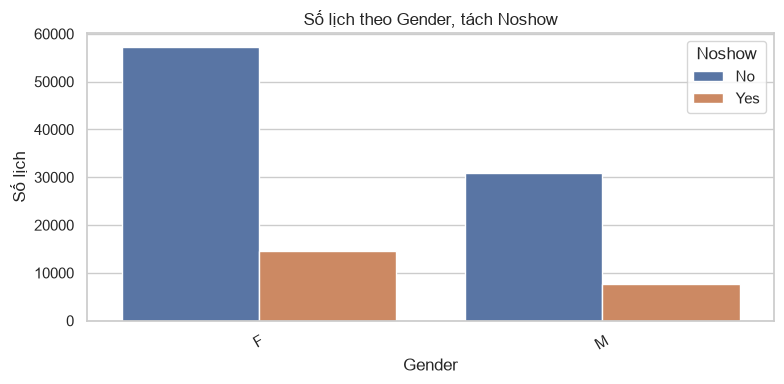

---------- Scholarship ----------


Scholarship
0    99665
1    10861
Name: count, dtype: int64

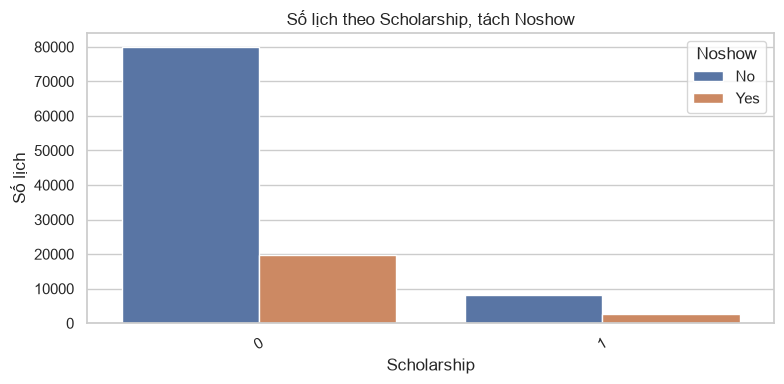

---------- Hypertension ----------


Hypertension
0    88725
1    21801
Name: count, dtype: int64

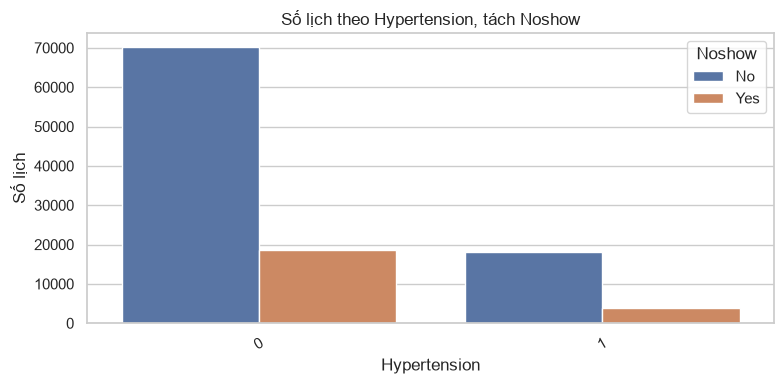

---------- Diabetes ----------


Diabetes
0    102583
1      7943
Name: count, dtype: int64

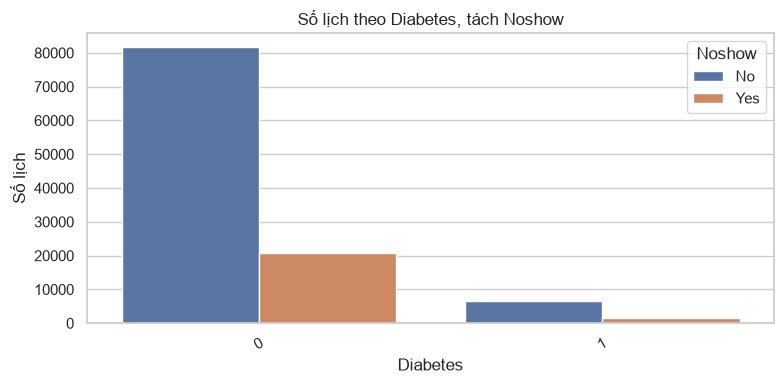

---------- Alcoholism ----------


Alcoholism
0    107166
1      3360
Name: count, dtype: int64

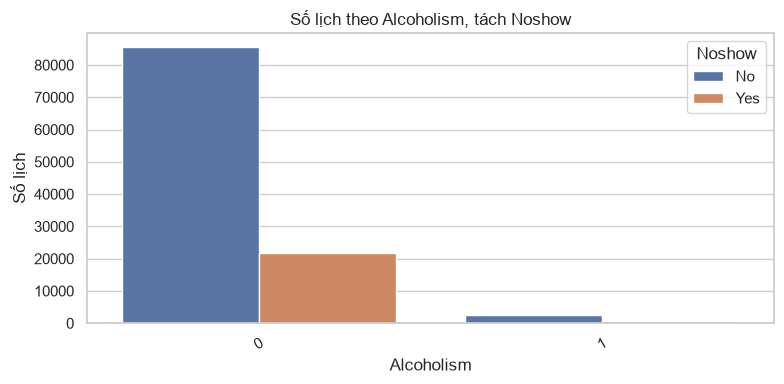

---------- Handicap ----------


Handicap
0    108285
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

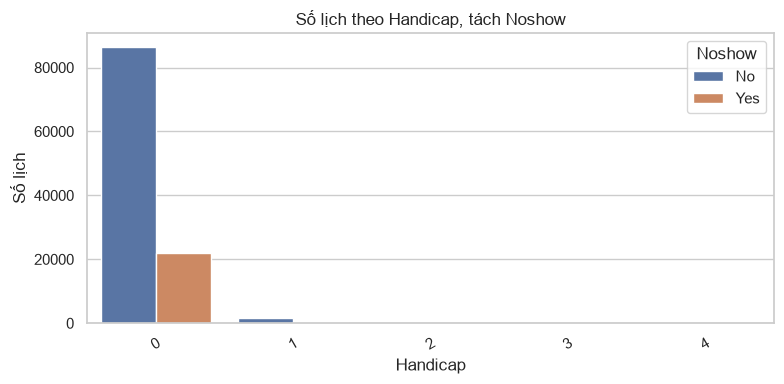

---------- SMSreceived ----------


SMSreceived
0    75044
1    35482
Name: count, dtype: int64

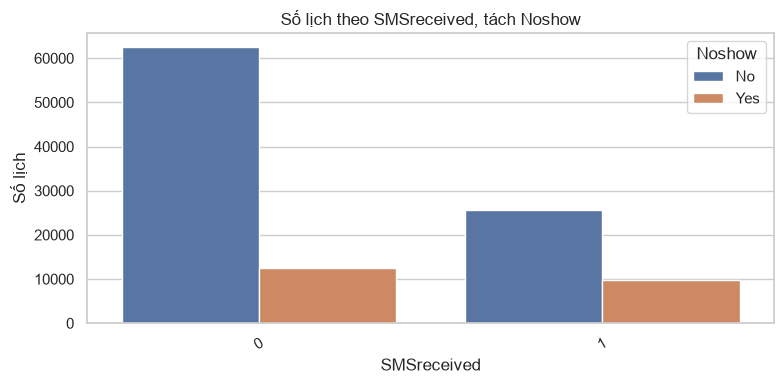

---------- sch_weekday ----------


sch_weekday
1    26168
2    24262
0    23084
4    18915
3    18073
5       24
Name: count, dtype: int64

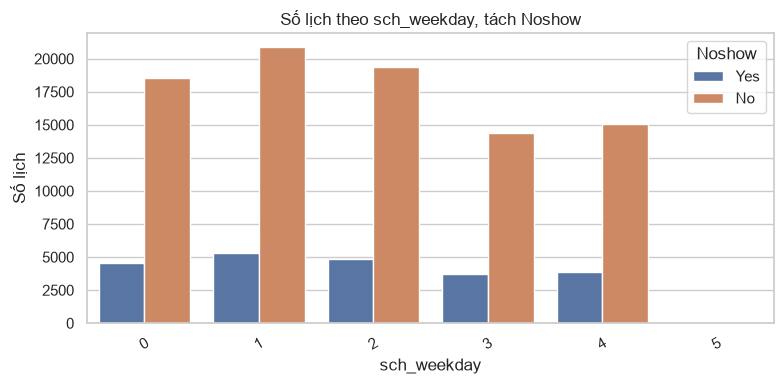

---------- app_weekday ----------


app_weekday
2    25867
1    25640
0    22714
4    19019
3    17247
5       39
Name: count, dtype: int64

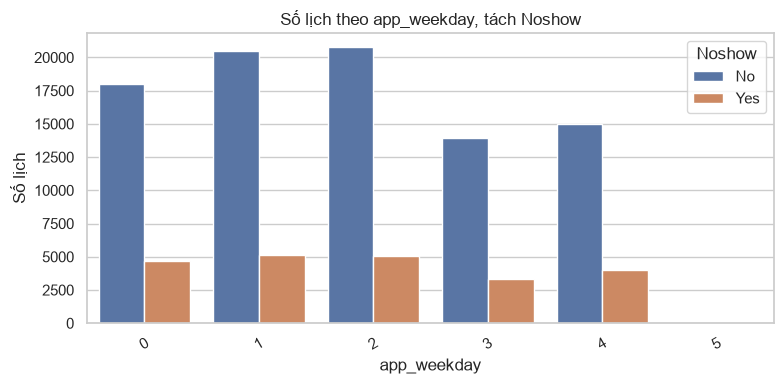

---------- Age_group ----------


Age_group
41 - 60      30081
21 - 40      28835
1 - 20       28309
61 - 80      16910
NaN           3539
81 - 100      2845
101 - 120        7
Name: count, dtype: int64

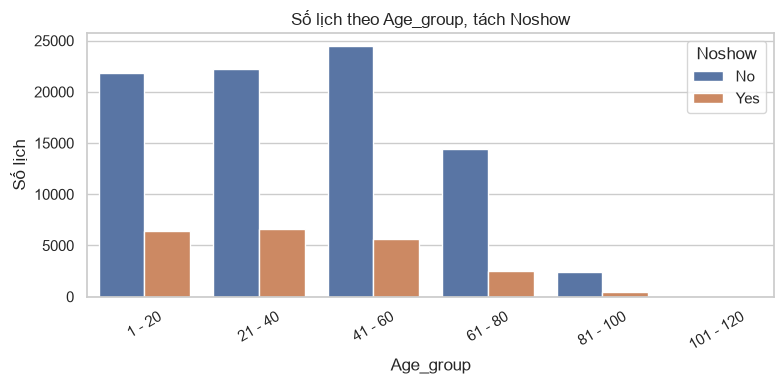

In [20]:
plot_cols = [
    "Gender",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMSreceived",
    "sch_weekday",
    "app_weekday",
    "Age_group",
]

for predictor in plot_cols:
    print("-" * 10, predictor, "-" * 10)
    display(df[predictor].value_counts(dropna=False))
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=predictor, hue="Noshow")
    plt.title(f"Số lịch theo {predictor}, tách Noshow")
    plt.xlabel(predictor)
    plt.ylabel("Số lịch")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Tự trả lời**

Đọc các hình đếm rồi trả lời. Mỗi câu phải có số lấy từ hình.

1. Giới nào đặt nhiều lịch hơn, mỗi giới bao nhiêu lịch? Tỷ lệ có mặt của hai giới chênh nhau bao nhiêu?
2. Ở các cờ học bổng, tăng huyết áp, đái tháo đường, nghiện rượu và SMS, mức nào chiếm phần lớn?
3. `Handicap` tập trung ở những mức nào? Mức 2–4 có bao nhiêu dòng, vì sao không nên đọc cột này như biến chỉ có 0 và 1?
4. Ba nhóm tuổi đông nhất mỗi nhóm khoảng bao nhiêu lịch? Nhóm 101–121 có bao nhiêu dòng?


#### Trả lời:
1. Nữ giới đặt nhiều lịch hơn với 71.839 lịch, trong khi nam giới có 38687 lịch. Tỷ lệ có mặt có 2 giới rất tương đồng, gần như không có sự chênh lệch.
2. Ở các cờ học bổng, tăng huyết áp, đái tháo đường, nghiện rượu và SMS, mức 0 đều chiếm phần lớn áp đảo.
3. Handicap tập trung ở mức 0, và 1 phần nhỏ ở mức 1. Mức 2-4 có tổng cộng 199 dòng (trong đó mức 2 có 183 dòng, mức 3 có 13 dòng, mức 4 có 3 dòng). Không nên xử lý cột này như một biến chỉ có 0 và 1 vì bản thân dữ liệu tồn tại các giá trị phân cấp (2, 3, 4), nếu ép về 0 và 1 sẽ làm mất hoặc sai lệch thông tin của 199 trường hợp này.
4. Ba nhóm tuổi đông nhất bao gồm: 41–60 (30.081 lịch), 21–40 (28.835 lịch) và 1–20 (28.309 lịch). Nhóm tuổi 101–120 có 7 dòng.

### 5.1. Tỷ lệ có mặt theo từng nhóm

Đếm tuyệt đối dễ bị nhóm đông chi phối. Bảng dưới là **tỷ lệ có đến** (`Noshow = No`) trong từng mức.


In [21]:
def show_rate_table(frame, column):
    grouped = (
        frame.groupby(column, dropna=False)["Noshow"]
        .agg(
            n="size",
            n_show=lambda s: int((s == "No").sum()),
            show_rate=lambda s: (s == "No").mean(),
        )
        .sort_index()
    )
    grouped["show_rate"] = grouped["show_rate"].map(lambda x: f"{x:.2%}")
    return grouped

for column in ["Gender", "Scholarship", "Hypertension", "Diabetes", "Alcoholism", "SMSreceived", "Age_group"]:
    print(column)
    display(show_rate_table(df, column))


Gender


,n,n_show,show_rate
Gender,,,
F,71839,57245,79.69%
M,38687,30962,80.03%


Scholarship


,n,n_show,show_rate
Scholarship,,,
0,99665,79924,80.19%
1,10861,8283,76.26%


Hypertension


...

,n,n_show,show_rate
Alcoholism,,,
0,107166,85524,79.81%
1,3360,2683,79.85%


SMSreceived


,n,n_show,show_rate
SMSreceived,,,
0,75044,62509,83.30%
1,35482,25698,72.43%


Age_group


,n,n_show,show_rate
Age_group,,,
1 - 20,28309,21852,77.19%
21 - 40,28835,22209,77.02%
41 - 60,30081,24490,81.41%
61 - 80,16910,14373,85.00%
81 - 100,2845,2379,83.62%
101 - 120,7,4,57.14%
NaN,3539,2900,81.94%


**Tự trả lời**

Đọc bảng tỷ lệ có đến (`Noshow = No`) rồi trả lời. Mỗi câu phải có số lịch và phần trăm.

Lịch trong ngày thường không kịp gửi SMS, và tỷ lệ đến của lịch trong ngày vốn cao. Cột SMS dính với số ngày chờ.

1. Học bổng: mức không có và mức có, tỷ lệ có đến mỗi mức là bao nhiêu? Chênh khoảng bao nhiêu điểm phần trăm?
2. Tăng huyết áp và đái tháo đường: mức có bệnh có tỷ lệ có đến cao hơn hay thấp hơn mức không bệnh? Mỗi mức bao nhiêu phần trăm?
3. SMS: mức không nhận và mức có nhận, tỷ lệ có đến là bao nhiêu? Vì sao chưa kết luận "nhắn tin làm bệnh nhân vắng"?
4. Nhóm tuổi nào có tỷ lệ có đến thấp hơn, nhóm nào cao nhất trong các nhóm đủ lớn? Nghiện rượu có làm đổi tỷ lệ có mặt không?


#### Trả lời:
1. Học bổng: Mức không có học bổng (0) có 79.924 lịch đến,với tỷ lệ 80,19%. Mức có học bổng (1) có 8.283 lịch đến, với tỷ lệ 76,26%. Nhóm không có học bổng có tỷ lệ đến cao hơn nhóm có học bổng khoảng 3,93 điểm phần trăm.
2. Tăng huyết áp và đái tháo đường: Ở cả 2 loại bệnh, mức có bênh đều có tỷ lệ đến cao hơn mức không bệnh.
- Tăng huyết áp: Mức có bệnh đạt 82,70% (18.029 lịch đến), cao hơn mức không bệnh là 79,10% (70.178 lịch đến).   
- Đái tháo đường: Mức có bệnh đạt 82,00% (6.513 lịch đến), cao hơn mức không bệnh là 79,64% (81.694 lịch đến).
3. SMS: Mức không nhận tin nhắn (0) có tỷ lệ đến là 83,30% (62.509 lịch đến), trong khi mức có nhận tin nhắn (1) có tỷ lệ đến thấp hơn, đạt 72,43% (25.698 lịch đến). Dù số liệu thấp hơn, ta chưa thể kết luận "nhắn tin làm bệnh nhân vắng" vì biến SMS có dính với số ngày chờ: những lịch hẹn ngay trong ngày vốn có tỷ lệ đến khám rất cao nhưng lại không kịp để hệ thống gửi SMS, trong khi những lịch nhận được SMS thường là lịch đặt trước dài ngày, và chính sự chờ đợi lâu này có thể nguyên nhân làm tăng khả năng bệnh nhân quên hoặc bỏ lịch.
4. nhóm 21–40 tuổi có tỷ lệ đến thấp nhất ở mức 77,02% (22.209 lịch đến), và nhóm 61–80 tuổi có tỷ lệ cao nhất ở mức 85,00% (14.373 lịch đến). Nghiện rượu hầu như không làm thay đổi tỷ lệ có mặt của bệnh nhân. Tỷ lệ có mặt ở mức không nghiện là 79,81% (85.524 lịch đến) và mức có nghiện là 79,85% (2.683 lịch đến), chênh lệch chỉ vỏn vẹn 0,04%.

## 6. Tương quan sau khi tạo biến giả

`Noshow` được mã hóa `Yes → 1` (vắng), `No → 0` (có đến) để lấy tương quan Pearson. Biến phân loại (`Gender`, `Age_group`) được tách thành cột 0/1. Cột ngày thô không đưa vào ma trận, vì đã có `sch_weekday` và `app_weekday`.


In [22]:
# Drop ScheduledDay, AppointmentDay, and Age. Code Noshow so Yes → 1 (absent) and No → 0 (showed). Turn the remaining categorical columns into 0/1 dummy columns (dtype=float). How many rows are coded 0 and how many are coded 1?
# Bỏ ScheduledDay, AppointmentDay và Age. Mã hóa Noshow: Yes → 1 (vắng), No → 0 (có đến). Tách các cột phân loại còn lại thành cột 0/1 (dtype=float). Có bao nhiêu dòng mã 0 và bao nhiêu dòng mã 1?

model_df = df.drop(columns=['ScheduledDay', 'AppointmentDay', 'Age']).copy()
model_df["Noshow"] = np.where(model_df["Noshow"].eq("Yes"), 1, 0)
print(model_df["Noshow"].value_counts())

data_dummies = pd.get_dummies(model_df, dtype=float)
data_dummies.head()


Noshow
0    88207
1    22319
Name: count, dtype: int64


,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSreceived,Noshow,sch_weekday,app_weekday,Gender_F,Gender_M,Age_group_1 - 20,Age_group_21 - 40,Age_group_41 - 60,Age_group_61 - 80,Age_group_81 - 100,Age_group_101 - 120
0,0,1,0,0,0,0,0,4,4,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,0,0,0,0,0,0,0,4,4,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00
2,0,0,0,0,0,0,0,4,4,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
3,0,0,0,0,0,0,0,4,4,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
4,0,1,1,0,0,0,0,4,4,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


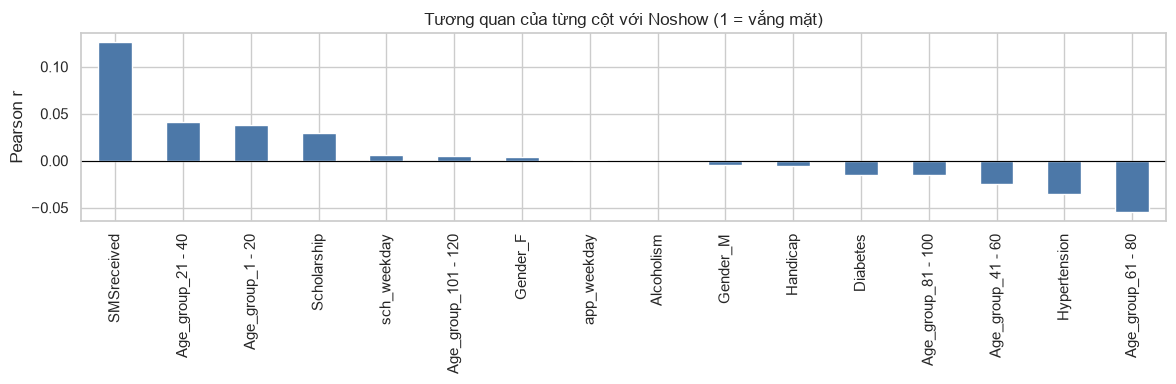

,corr_with_noshow
SMSreceived,0.13
Age_group_21 - 40,0.04
Age_group_1 - 20,0.04
Scholarship,0.03
sch_weekday,0.01
Age_group_101 - 120,0.00
Gender_F,0.00
app_weekday,0.00
Alcoholism,-0.00
Gender_M,-0.00


In [23]:
# What is the Pearson correlation of each dummy column with Noshow (1 = absent)? Drop Noshow itself, sort from highest to lowest (ascending=False), and draw a vertical bar chart (kind="bar").
# Tương quan Pearson của từng cột biến giả với Noshow (1 = vắng) là bao nhiêu? Bỏ chính cột Noshow, sắp từ cao xuống thấp (ascending=False), rồi vẽ biểu đồ cột đứng (kind="bar").

corr_target = (
    data_dummies.corr(numeric_only=True)[ "Noshow" ]
    .drop(labels=["Noshow"])
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
corr_target.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Tương quan của từng cột với Noshow (1 = vắng mặt)")
ax.set_xlabel("")
ax.set_ylabel("Pearson r")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
corr_target.to_frame("corr_with_noshow")


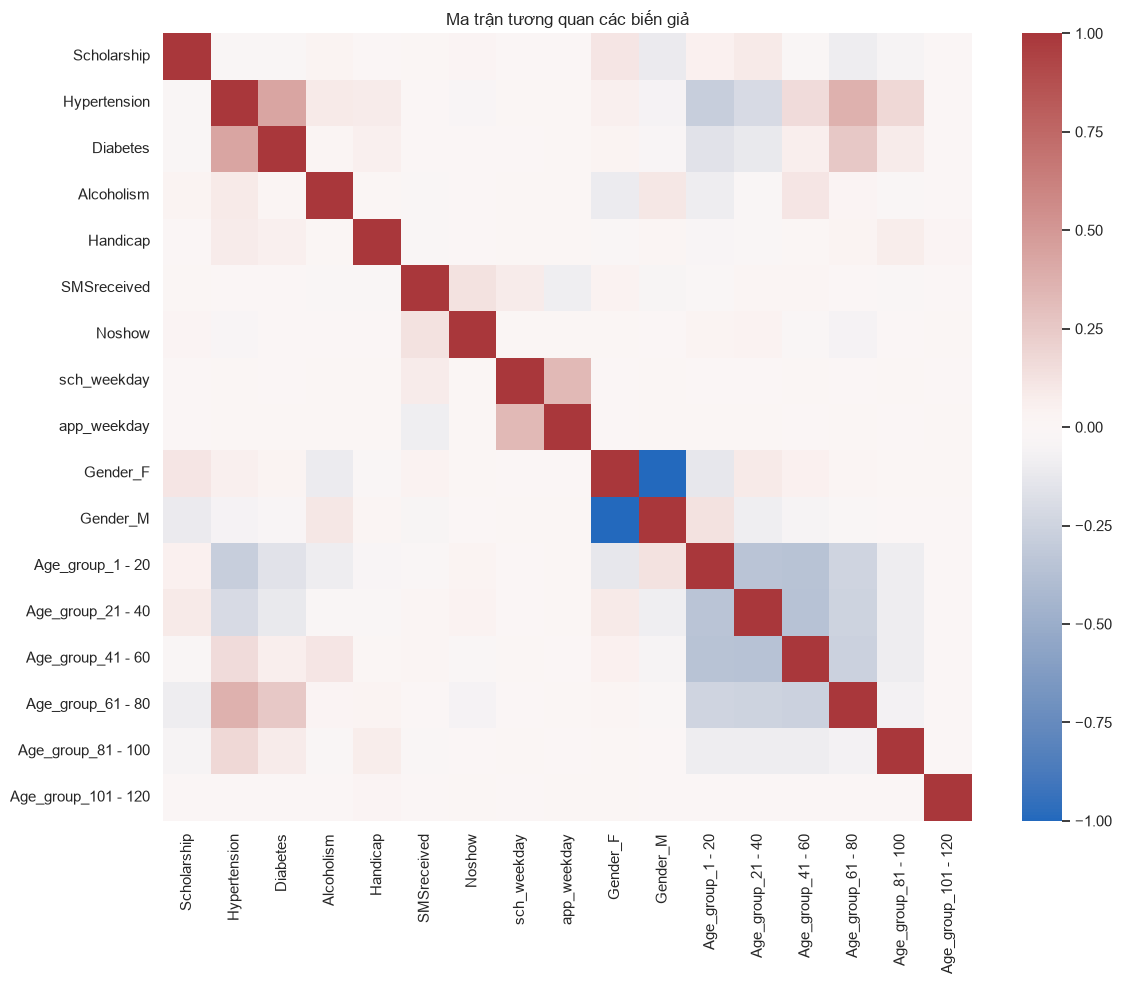

In [32]:
# Draw a heatmap of the correlation matrix of the dummy columns: data_dummies.corr(numeric_only=True), center=0.
# Vẽ heatmap ma trận tương quan các biến giả: data_dummies.corr(numeric_only=True), center=0.

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    data_dummies.corr(numeric_only=True),
    cmap="vlag",
    center=0,
    ax=ax
)
ax.set_title("Ma trận tương quan các biến giả")
plt.tight_layout()
plt.show()


**Tự trả lời**

Đọc biểu đồ cột và heatmap rồi trả lời. Nêu tên cột và hệ số đọc được.

1. Các hệ số với `Noshow` lớn hay gần 0? Cột nào dương rõ nhất (đi cùng vắng mặt cao hơn)? Những cột nào âm nhẹ?
2. Trên heatmap, các cột giả của cùng một biến (hai mức giới tính, các nhóm tuổi) tương quan với nhau theo hướng nào? Đó là quan hệ y khoa hay hệ quả của cách tách biến giả?
3. Có cặp đặc trưng nào đủ mạnh để nói yếu tố đó quyết định việc vắng mặt không?


#### Trả lời:
1. Các hệ số với NoShow đều rất nhỏ gần bằng 0, dao động trong khoảng từ -0.05 đến 0.13. Cột có hệ số dương rõ nhất là SMSreceived với mức 0.13. Những cột hệ số âm nhẹ bao gồm Age_group_61 - 80 (-0.05), Hypertension (-0.04), Age_group_41 - 60 (-0.02), Age_group_81 - 100 (-0.02) và Diabetes (-0.02).
2. Trên heatmap, các cột giả của cùng một biến (hai mức giới tính, các nhóm tuổi) tương quan âm rất mạnh với nhau. Cụ thể, Gender_F tương quan âm gần tuyệt đối (-1.00) với Gender_M, và các Age_group cũng tương quan âm chéo với nhau. Đây không phải là quan hệ y khoa mà hoàn toàn là hệ quả của cách tách biến giả.
3. hông có đặc trưng nào đủ mạnh để quyết định việc vắng mặt.

## 7. Bivariate analysis

Tách hai tập: có đến (`Noshow = 0`) và vắng mặt (`Noshow = 1`). Hàm `uniplot` vẽ số lượng theo một cột, tô màu theo cột thứ hai. Trục y dùng thang log vì các mức 0/1 chênh nhau rất lớn.


In [33]:
# Split into two tables: showed up is Noshow == 0, absent is Noshow == 1. How many rows are in each?
# Tách hai bảng: có đến là Noshow == 0, vắng mặt là Noshow == 1. Mỗi bảng có bao nhiêu dòng?

showed = model_df.loc[model_df["Noshow"] == 0].copy()
missed = model_df.loc[model_df["Noshow"] == 1].copy()
print("Có đến:", len(showed), "| Vắng mặt:", len(missed))


def uniplot(frame, col, title, hue=None):
    sns.set_style("whitegrid")
    sns.set_context("notebook")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(
        data=frame,
        x=col,
        order=frame[col].value_counts(dropna=False).index,
        hue=hue,
        palette="bright",
        ax=ax,
    )
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Số lịch (thang log)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


Có đến: 88207 | Vắng mặt: 22319


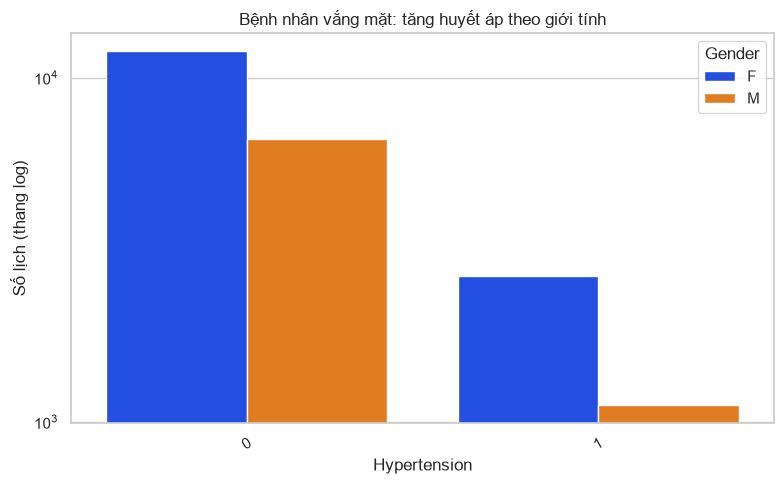

In [ ]:
uniplot(
    missed,
    col="Hypertension",
    title="Bệnh nhân vắng mặt: tăng huyết áp theo giới tính",
    hue="Gender",
)


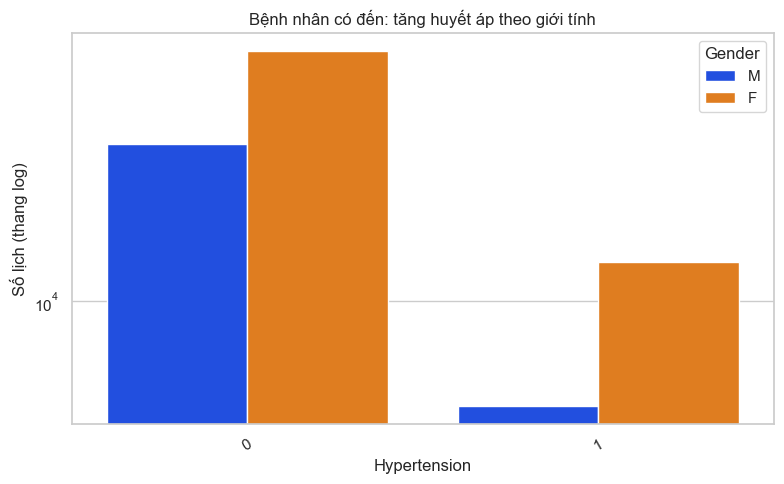

In [ ]:
uniplot(
    showed,
    col="Hypertension",
    title="Bệnh nhân có đến: tăng huyết áp theo giới tính",
    hue="Gender",
)


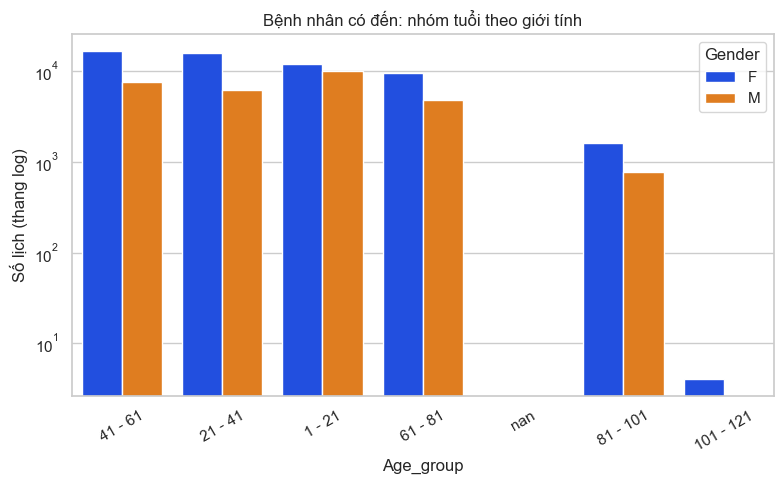

In [ ]:
uniplot(
    showed,
    col="Age_group",
    title="Bệnh nhân có đến: nhóm tuổi theo giới tính",
    hue="Gender",
)


**Tự trả lời**

Đọc ba hình rồi trả lời.

1. Ở nhóm có đến và nhóm vắng, mức tăng huyết áp nào đông hơn? Cột nữ hay cột nam cao hơn? Điều đó đã đủ để nói nhóm vắng mặt có một tương tác riêng chưa?
2. Trong nhóm có đến, nữ và nam khác nhau thế nào theo nhóm tuổi? Nhóm 101–121 có thấy rõ trên hình không? Vì sao?


#### Trả lời
1. Ở cả nhóm có đến và nhóm vắng, mức tăng huyết áp 0 (không bệnh) đều đông hơn rất nhiều so với mức 1. Cột Nữ luôn cao hơn cột Nam ở tất cả các mức của cả hai nhóm. Hiện tượng này chưa đủ để nói nhóm vắng mặt có tương tác riêng biệt. Việc cột nữ luôn cao hơn chỉ đơn thuần phản ánh bản chất của bộ dữ liệu gốc là số lượng bệnh nhân nữ áp đảo nam giới.
2. Trong nhóm có đến, nữ giới đi khám nhiều hơn nam giới ở hầu hết các độ tuổi (như 21–41, 41–61, 61–81, 81–101), ngoại trừ nhóm tuổi 1–21 có số lượng nam và nữ ngang bằng nhau. Nhóm tuổi 101–121 có thấy rõ trên hình, chỉ có một vạch xanh rất thấp của nữ và nam hoàn toàn biến mất. Vì số lượng bệnh nhân thực tế ở độ tuổi này quá ít, cộng thêm việc trục tung đang sử dụng thang đo logarit (log scale) khiến các giá trị rất nhỏ bị ép sát xuống đáy và các giá trị bằng 0 (của nam) không thể hiển thị trên đồ thị.

## 8. Kết luận

Điền kết quả đã tính ở các phần trên. Mỗi ô phải có số.

| Câu hỏi | Kết quả |
| --- | --- |
| Dữ liệu là gì? Nhãn `Noshow` đọc thế nào? | Gồm 110.527 lịch hẹn. Nhãn No (88.208) là có đến, Yes (22.319) là vắng mặt |
| Thiếu dữ liệu? | 0% thiếu ở các cột gốc. Cột Age_group thiếu 3.539 dòng do cách chia bin. |
| Tỷ lệ đến? | Nhóm "No" (có đến) chiếm khoảng 80%. |
| Thứ trong tuần? | Thứ 2, 3, 4 đông nhất (>20.000 lịch). Thứ 7 có rất ít (24 lịch). Chủ Nhật (mã 6) có 0 lịch. |
| Giới tính? | Nữ đông hơn (71.839) so với Nam (38.687). Tỷ lệ đến tương đồng: Nữ 79,69%, Nam 80,03%. |
| Học bổng? | Mức không có (0) chiếm 99.665 lịch. Tỷ lệ đến của mức 0 là 80,19%, cao hơn mức 1 (76,26%). |
| Tăng huyết áp? | Mức không bệnh (0) chiếm 88.725 lịch. Tỷ lệ đến của mức 1 (82,70%) cao hơn mức 0 (79,10%). |
| Đái tháo đường? | Mức không bệnh (0) chiếm 102.583 lịch. Tỷ lệ đến của mức 1 (82,00%) cao hơn mức 0 (79,64%). |
| SMS? | Nhóm không nhận SMS (0) chiếm 75.044 lịch. Tỷ lệ đến của nhóm 0 là 83,30%, cao hơn nhóm 1 (72,43%) |
| Khu phố? | Drop |
| Nhóm tuổi? | 41-60 tuổi đông nhất (30.081). Tỷ lệ đến thấp nhất ở 21-40 (77,02%), cao nhất ở 61-80 (85,00%). |


